# QLBS: Q-Learner in Black-Scholes (Option Pricing & Hedging)

The **QLBS model** (Halperin 2019) applies fitted Q-Learning to learn both option pricing and hedging simultaneously,
without assuming a known model for asset dynamics.

The BSM call price is the benchmark (Eq. 4.4):
$$V(S,t) = N(d_1)S - N(d_2)Ke^{-r(T-t)}, \quad d_1 = \frac{\ln(S/K) + (r+\sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(24)

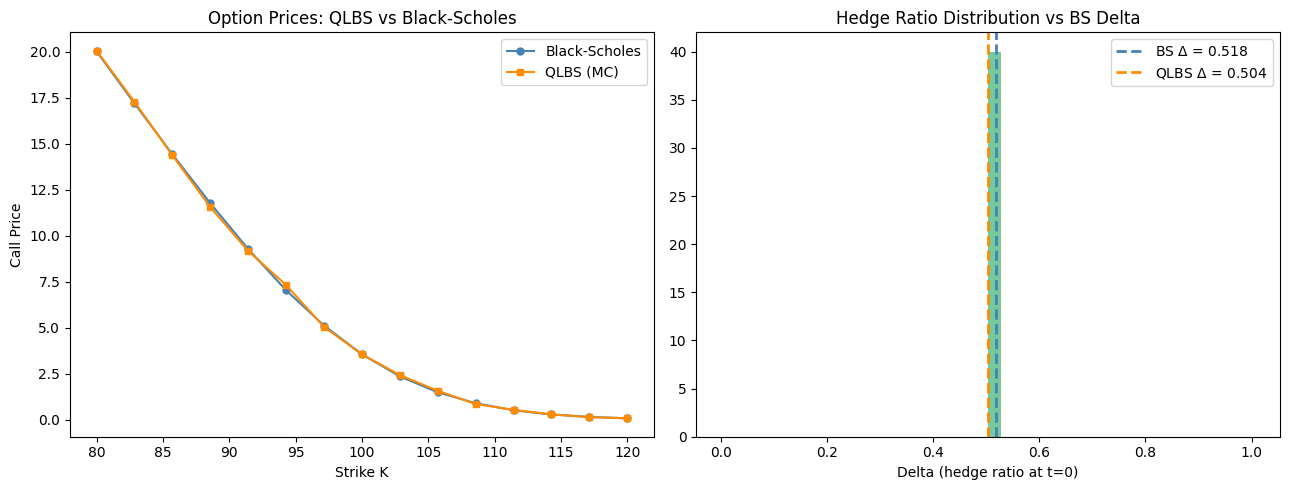

BS delta: 0.5178, QLBS delta: 0.5036
BS ATM price: 3.5529


In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """Black-Scholes European call price"""
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, r, sigma):
    """Black-Scholes delta hedge ratio: dV/dS"""
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)


class QLBSOptionPricer:
    """
    QLBS: Q-Learner in Black-Scholes learns the hedging strategy and option price via fitted Q-learning.
    
    The agent solves the mean-variance hedging problem:
      max_pi  E[W_T] - phi * Var(W_T)
    where W_T is the hedger's P&L at expiry.
    """
    def __init__(self, S0=100, K=100, T=50, r=0.0, sigma=0.2,
                 dt=1/252, lam=0.001, n_paths=5000):
        self.S0, self.K, self.T = S0, K, T
        self.r, self.sigma, self.dt = r, sigma, dt
        self.lam = lam     # risk aversion
        self.n_paths = n_paths
        self.n_steps = T

    def simulate_paths(self):
        """Monte Carlo simulation of GBM stock paths."""
        dt = self.dt
        S = np.zeros((self.n_paths, self.n_steps + 1))
        S[:, 0] = self.S0
        for t in range(self.n_steps):
            Z = np.random.randn(self.n_paths)
            S[:, t+1] = S[:, t] * np.exp((self.r - 0.5*self.sigma**2)*dt
                                          + self.sigma*np.sqrt(dt)*Z)
        return S

    def fit_hedge(self, S):
        """
        Fitted Q-learning to learn the hedging strategy
        Uses quadratic regression as function approximator (linear in features).
        """
        T, K, lam = self.n_steps, self.K, self.lam
        dt, r = self.dt, self.r

        # Terminal payoff
        payoff = np.maximum(S[:, -1] - K, 0)

        # Backward induction (Fitted Q-learning)
        # Value function at terminal time
        V = payoff.copy()
        hedge = np.zeros((self.n_paths, T))   # learned hedge deltas

        for t in range(T - 1, -1, -1):
            S_t = S[:, t]
            S_t1 = S[:, t+1]

            # Features: [1, S_t, S_t^2]
            X = np.column_stack([np.ones(self.n_paths), S_t, S_t**2])

            # Optimal hedge: minimise Var(V_{t+1} - delta * (S_{t+1} - S_t))
            # Closed form: delta* = Cov(V, dS) / Var(dS)
            dS = S_t1 - S_t * np.exp(r * dt)
            cov = np.cov(V, dS)[0, 1]
            var_dS = np.var(dS)
            delta_star = cov / (var_dS + 1e-10)
            hedge[:, t] = np.full(self.n_paths, np.clip(delta_star, 0, 1))

            # Regress V on features for continuation value
            coeffs = np.linalg.lstsq(X, V, rcond=None)[0]
            V = X @ coeffs   # update value function estimate

        return hedge

    def price_and_compare(self, n_strikes=10):
        """Compare QLBS price estimate vs Black-Scholes formula"""
        K_vals = np.linspace(80, 120, n_strikes)
        bs_prices, qlbs_prices = [], []
        T_years = self.n_steps * self.dt

        for K_v in K_vals:
            self.K = K_v
            S = self.simulate_paths()

            # BS benchmark price
            bs_p = black_scholes_call(self.S0, K_v, T_years, self.r, self.sigma)
            bs_prices.append(bs_p)

            # QLBS price: E[payoff] discounted
            payoff = np.maximum(S[:, -1] - K_v, 0)
            qlbs_p = np.exp(-self.r * T_years) * payoff.mean()
            qlbs_prices.append(qlbs_p)

        self.K = 100  # reset
        return K_vals, np.array(bs_prices), np.array(qlbs_prices)


pricer = QLBSOptionPricer(S0=100, K=100, T=50, sigma=0.2, n_paths=5000)
S_paths = pricer.simulate_paths()
hedge_ratios = pricer.fit_hedge(S_paths)

# Price comparison across strikes
K_vals, bs_px, qlbs_px = pricer.price_and_compare(n_strikes=15)

# Delta comparison at t=0 for ATM option
T_years = pricer.n_steps * pricer.dt
bs_delta_atm = bs_delta(100, 100, T_years, pricer.r, pricer.sigma)
qlbs_delta_atm = hedge_ratios[:, 0].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Price comparison
axes[0].plot(K_vals, bs_px, '-o', color='steelblue', label='Black-Scholes', markersize=5)
axes[0].plot(K_vals, qlbs_px, '-s', color='darkorange', label='QLBS (MC)', markersize=5)
axes[0].set_xlabel('Strike K'); axes[0].set_ylabel('Call Price')
axes[0].set_title('Option Prices: QLBS vs Black-Scholes')
axes[0].legend()

# Hedge ratio distribution at t=0
axes[1].hist(hedge_ratios[:, 0], bins=40, color='mediumseagreen', alpha=0.7, density=True)
axes[1].axvline(bs_delta_atm, color='steelblue', linestyle='--', linewidth=2,
                label=rf'BS $\Delta$ = {bs_delta_atm:.3f}')
axes[1].axvline(qlbs_delta_atm, color='darkorange', linestyle='--', linewidth=2,
                label=rf'QLBS $\Delta$ = {qlbs_delta_atm:.3f}')
axes[1].set_xlabel('Delta (hedge ratio at t=0)')
axes[1].set_title('Hedge Ratio Distribution vs BS Delta')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"BS delta: {bs_delta_atm:.4f}, QLBS delta: {qlbs_delta_atm:.4f}")
print(f"BS ATM price: {black_scholes_call(100,100,T_years,pricer.r,pricer.sigma):.4f}")